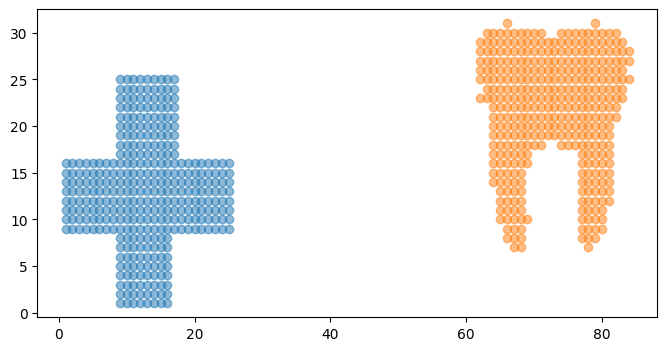

In [2]:
import numpy as np
import matplotlib.pylab as pl
import torch
import ot
import matplotlib.animation as animation

I1 = pl.imread("../data/redcross.png").astype(np.float64)[::5, ::5, 2]
I2 = pl.imread("../data/tooth.png").astype(np.float64)[::5, ::5, 2]

sz = I2.shape[0]
XX, YY = np.meshgrid(np.arange(sz), np.arange(sz))

x1 = np.stack((XX[I1 == 0], YY[I1 == 0]), 1) * 1.0
x2 = np.stack((XX[I2 == 0] + 60, -YY[I2 == 0] + 32), 1) * 1.0
x3 = np.stack((XX[I2 == 0], -YY[I2 == 0] + 32), 1) * 1.0

pl.figure(1, [8, 4])
pl.scatter(x1[:, 0], x1[:, 1], alpha=0.5)
pl.scatter(x2[:, 0], x2[:, 1], alpha=0.5)

## Sliced Wasserstein gradient flow with Pytorch

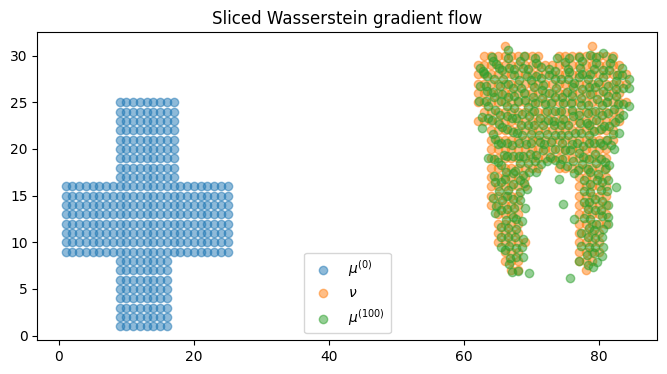

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

x1_torch = torch.tensor(x1).to(device=device).requires_grad_(True)
x2_torch = torch.tensor(x2).to(device=device)

lr = 1e3
nb_iter_max = 50

x_all = np.zeros((nb_iter_max, x1.shape[0], 2))

loss_iter = []

# generator for random permutation
gen = torch.Generator(device=device)
gen.manual_seed(42)

for i in range(nb_iter_max):
    loss = ot.sliced_wasserstein_distance(x1_torch, x2_torch, n_projections=20, seed=gen)
    loss_iter.append(loss.clone().detach().cpu().numpy())
    loss.backward()

    # perfrom a step of projected gradient descent
    with torch.no_grad():
        grad = x1_torch.grad
        x1_torch -= grad * lr / (1 + i / 5e1) # step
        x1_torch.grad.zero_()
        x_all[i, :, :] = x1_torch.clone().detach().cpu().numpy()

xb = x1_torch.clone().detach().cpu().numpy()

pl.figure(2, (8, 4))
pl.scatter(x1[:, 0], x1[:, 1], alpha=0.5, label="$\mu^{(0)}$")
pl.scatter(x2[:, 0], x2[:, 1], alpha=0.5, label=r"$\nu$")
pl.scatter(xb[:, 0], xb[:, 1], alpha=0.5, label="$\mu^{(100)}$")
pl.title("Sliced Wasserstein gradient flow")
pl.legend()
ax = pl.axis()

## Animate trajectories of the gradient flow along iteration

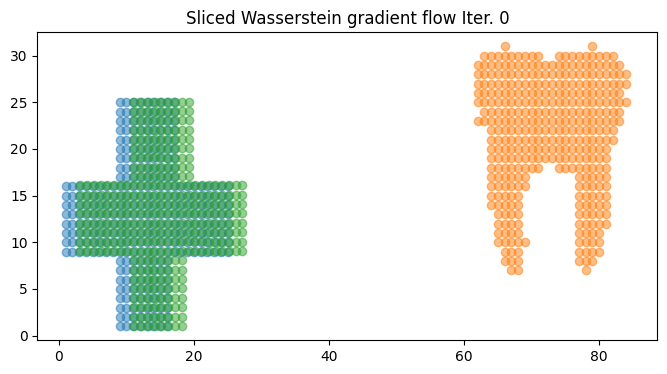

In [13]:
pl.figure(3, (8, 4))

def _update_plot(i):
    pl.clf()
    pl.scatter(x1[:, 0], x1[:, 1], alpha=0.5, label="$\mu^{(0)}$")
    pl.scatter(x2[:, 0], x2[:, 1], alpha=0.5, label=r"$\nu$")
    pl.scatter(x_all[i, :, 0], x_all[i, : , 1], alpha=0.5, label="$\mu^{(100)}$")
    pl.title("Sliced Wasserstein gradient flow Iter. {}".format(i))
    pl.axis(ax)
    return 1

ani = animation.FuncAnimation(pl.gcf(),
                             _update_plot,
                             nb_iter_max,
                             interval=100,
                             repeat_delay=2000)

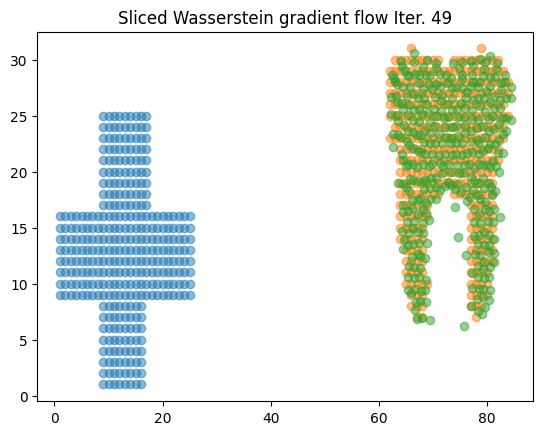

In [14]:
from IPython.display import HTML
HTML(ani.to_jshtml())